# Part B2 — Convolutional Neural Network (CNN) for image classification

**Dataset:** scikit-learn's `digits` dataset — 1,797 8x8 grayscale images of
handwritten digits (0-9). A note on this choice: this sandbox's network is
locked down to a short allow-list of domains (PyPI, GitHub, etc.) for
security, so the usual CIFAR-10/Fashion-MNIST auto-downloads (which pull
from Google/AWS storage buckets) aren't reachable here. `digits` ships
built into scikit-learn with no download at all, so it lets us build and
train a *real* CNN end-to-end. Architecturally, CIFAR-10 (32x32x3, 10
classes) and Fashion-MNIST (28x28x1, 10 classes) use the exact same
Conv2D -> pool -> dropout pattern shown below — only the input shape and
training time change.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)
np.random.seed(42)

I0000 00:00:1788431264.865653    1517 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788431264.916671    1517 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1788431266.452951    1517 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## Load and prepare the images

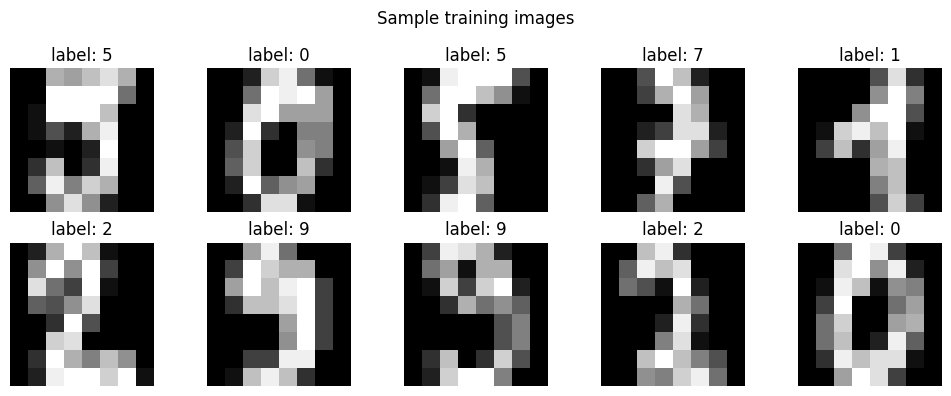

In [2]:
data = load_digits()
X = data.images  # (1797, 8, 8)
y = data.target

X = X.astype("float32") / 16.0  # pixel values are 0-16 in this dataset
X = np.expand_dims(X, -1)       # add channel dimension -> (1797, 8, 8, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i].squeeze(), cmap="gray")
    ax.set_title(f"label: {y_train[i]}")
    ax.axis("off")
plt.suptitle("Sample training images")
plt.tight_layout()
plt.savefig("cnn_sample_images.png", dpi=120)
plt.show()

## Data augmentation

With only ~1,440 training images, augmentation (small random rotations and
shifts) acts as free extra training data and makes the model less
sensitive to exactly how a digit is drawn.

In [3]:
augment = keras.Sequential([
    layers.RandomRotation(0.05),
    layers.RandomTranslation(0.1, 0.1),
])

## Build the CNN

- **Conv2D layers**: slide small filters across the image to learn local
  patterns (edges, curves) instead of treating every pixel independently
  like an ANN would — this is what makes CNNs suited to images.
- **MaxPooling**: shrinks the spatial size while keeping the strongest
  activations, giving some translation-invariance and fewer parameters.
- **Dropout**: same overfitting defense as the ANN, applied after the
  dense layer where most of the parameters live.

In [4]:
def build_cnn(input_shape, num_classes):
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        augment,
        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation="softmax"),
    ])
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

cnn = build_cnn(X_train.shape[1:], 10)
cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 8, 8, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 8, 8, 32)       │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 4, 4, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,914 (140.29 KB)

 Trainable params: 35,914 (140.29 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

history = cnn.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=60,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0,
)
print(f"Training stopped after {len(history.history['loss'])} epochs")

Training stopped after 50 epochs


## Evaluate

In [6]:
test_loss, test_acc = cnn.evaluate(X_test, y_test, verbose=0)
y_pred = np.argmax(cnn.predict(X_test, verbose=0), axis=1)

print(f"Test accuracy: {test_acc:.4f}")
print(classification_report(y_test, y_pred))

with open("cnn_report.txt", "w") as f:
    f.write(f"Test accuracy: {test_acc:.4f}\n\n")
    f.write(classification_report(y_test, y_pred))

Test accuracy: 0.9694
              precision    recall  f1-score   support

           0       1.00      0.97      0.99        36
           1       0.90      1.00      0.95        36
           2       1.00      1.00      1.00        35
           3       1.00      1.00      1.00        37
           4       0.97      1.00      0.99        36
           5       0.97      1.00      0.99        37
           6       0.97      0.97      0.97        36
           7       0.92      0.97      0.95        36
           8       1.00      0.80      0.89        35
           9       0.97      0.97      0.97        36

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360



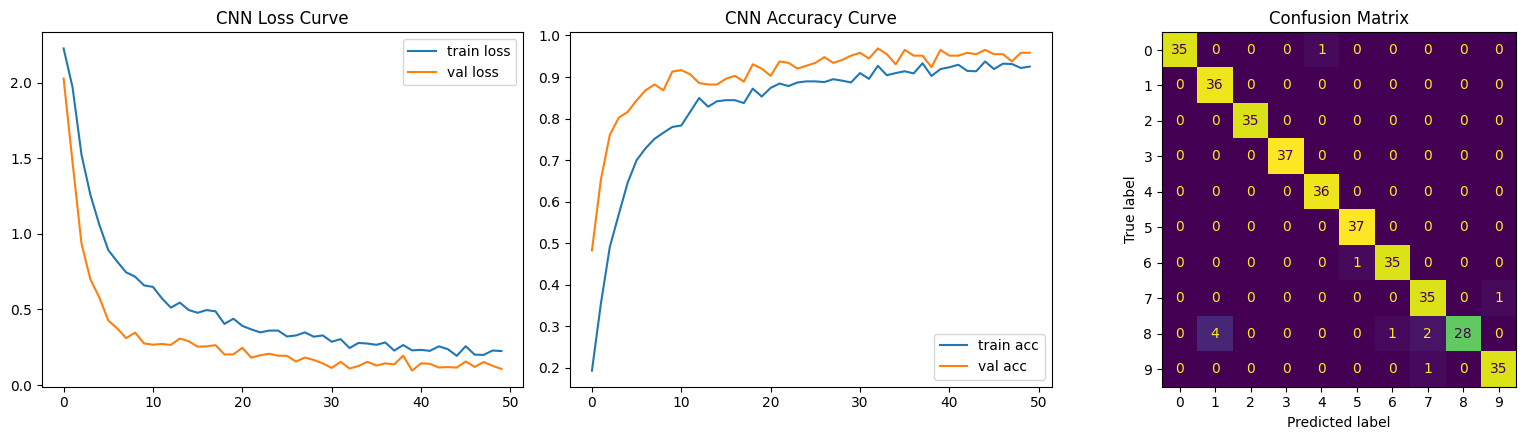

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(history.history["loss"], label="train loss")
axes[0].plot(history.history["val_loss"], label="val loss")
axes[0].set_title("CNN Loss Curve"); axes[0].legend()

axes[1].plot(history.history["accuracy"], label="train acc")
axes[1].plot(history.history["val_accuracy"], label="val acc")
axes[1].set_title("CNN Accuracy Curve"); axes[1].legend()

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot(ax=axes[2], colorbar=False)
axes[2].set_title("Confusion Matrix")

plt.tight_layout()
plt.savefig("cnn_training_curves.png", dpi=120)
plt.show()

## Summary

The convolutional layers let the network learn shape-based features (loops,
strokes, curves) that generalize across the natural variation in
handwriting, which is exactly the kind of spatial structure an ANN
(treating every pixel as an independent unordered feature) can't exploit
efficiently. Augmentation plus dropout kept the accuracy/loss curves close
together between train and validation, indicating the model generalizes
rather than memorizing the training images.